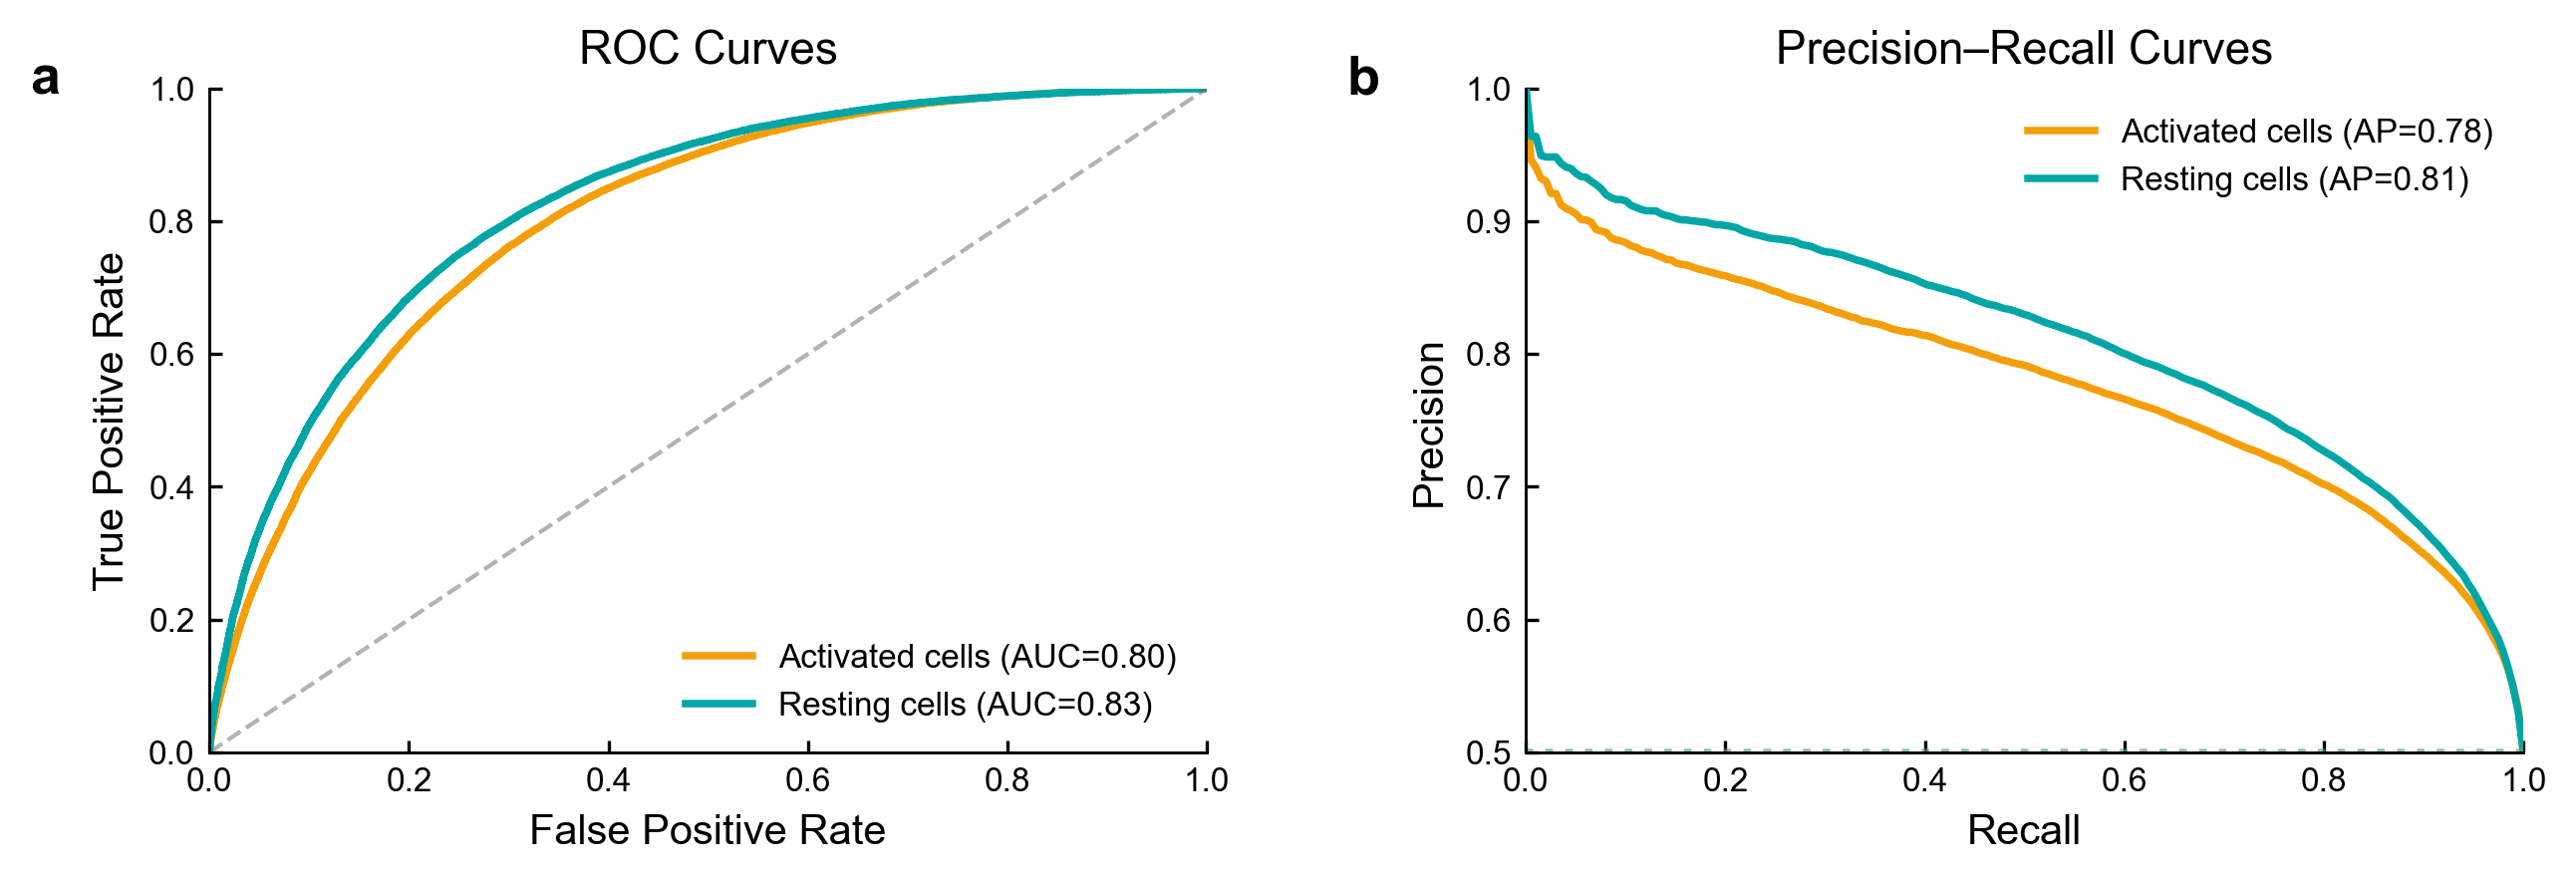

Figura generata:
 → ../images/AUC_PRAUC_fig.png


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],

    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,

    'figure.dpi': 300,
    'axes.linewidth': 0.7,
    'lines.linewidth': 1.8,

    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3,
    'ytick.major.size': 3,

    'legend.frameon': False,
})

COLOR_ACT = "#F49F0A"   
COLOR_REST = "#00A6A6"  
COLOR_BASE = "#666666"  

def get_smooth_pr_curve_custom(y_true, y_probs, points=200):
    """Interpolazione Precision-Recall più liscia, stile editoriale."""
    precision, recall, _ = precision_recall_curve(y_true, y_probs)

    recall_smooth = np.linspace(0, 1, points)
    precision_smooth = np.interp(recall_smooth, recall[::-1], precision[::-1])
    precision_smooth = np.maximum.accumulate(precision_smooth[::-1])[::-1]

    return recall_smooth, precision_smooth

def plot_nature_comparison(file_act, file_rest, save_path="../images/AUC_PRAUC_fig.png"):
    
    try:
        df_act = file_act
        df_rest = file_rest
    except FileNotFoundError as e:
        print(f"❌ Errore: {e}")
        return

    y_true_act, y_probs_act = df_act['y_true'], df_act['y_pred_probs']
    y_true_rest, y_probs_rest = df_rest['y_true'], df_rest['y_pred_probs']

    auc_act = roc_auc_score(y_true_act, y_probs_act)
    auc_rest = roc_auc_score(y_true_rest, y_probs_rest)
    ap_act = average_precision_score(y_true_act, y_probs_act)
    ap_rest = average_precision_score(y_true_rest, y_probs_rest)

    base_act = y_true_act.mean()
    base_rest = y_true_rest.mean()


    fig, axes = plt.subplots(
        1, 2,
        figsize=(8.6, 3.0),   
        constrained_layout=False
    )

    plt.subplots_adjust(wspace=0.32, left=0.08, right=0.98, top=0.92, bottom=0.18)

    # ------------------------------------------
    # ROC
    # ------------------------------------------
    ax_roc = axes[0]

    fpr_act, tpr_act, _ = roc_curve(y_true_act, y_probs_act)
    fpr_rest, tpr_rest, _ = roc_curve(y_true_rest, y_probs_rest)
    
    ax_roc.plot(fpr_act, tpr_act, color=COLOR_ACT, label=f'Activated cells (AUC={auc_act:.2f})')
    ax_roc.plot(fpr_rest, tpr_rest, color=COLOR_REST, label=f'Resting cells (AUC={auc_rest:.2f})')

    ax_roc.plot([0, 1], [0, 1], linestyle='--', color=COLOR_BASE, linewidth=1, alpha=0.5)

    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.set_xlim(0, 1)
    ax_roc.set_ylim(0, 1)

    ax_roc.legend(loc="lower right")

    ax_roc.text(-0.18, 1.05, "a", transform=ax_roc.transAxes,
                fontsize=13, fontweight="bold", ha="left", va="top")
    ax_roc.set_title("ROC Curves")


    # ------------------------------------------
    # PR
    # ------------------------------------------
    ax_pr = axes[1]

    rec_act, prec_act = get_smooth_pr_curve_custom(y_true_act, y_probs_act)
    rec_rest, prec_rest = get_smooth_pr_curve_custom(y_true_rest, y_probs_rest)

    ax_pr.plot(rec_act, prec_act, color=COLOR_ACT, label=f'Activated cells (AP={ap_act:.2f})')
    ax_pr.plot(rec_rest, prec_rest, color=COLOR_REST, label=f'Resting cells (AP={ap_rest:.2f})')

    ax_pr.axhline(base_act, linestyle=':', color=COLOR_ACT, alpha=0.4)
    ax_pr.axhline(base_rest, linestyle=':', color=COLOR_REST, alpha=0.4)

    ax_pr.set_xlabel("Recall")
    ax_pr.set_ylabel("Precision")
    ax_pr.set_xlim(0, 1)
    ax_pr.set_ylim(0.5, 1)

    ax_pr.legend(loc="upper right")

    ax_pr.text(-0.18, 1.05, "b", transform=ax_pr.transAxes,
               fontsize=13, fontweight="bold", ha="left", va="top")
    ax_pr.set_title("Precision–Recall Curves")

    plt.savefig(save_path, format="pdf")
    plt.savefig(save_path.replace(".pdf", ".png"), format="png", dpi=600)
    plt.show()

    print(f"Figura generata:\n → {save_path}")




######
#DATI
###
import pickle
from Bio.Seq import Seq

with open('../data/data_pkl/CD4T_h19_Act_tot_99_8_percentile.pkl', 'rb') as f:   
    dataset_sapiens_cd4t_act = pickle.load(f)
if True:
    for d1, d2 in zip(dataset_sapiens_cd4t_act, dataset_sapiens_cd4t_act):
        d1['sequence_rev'] = str(Seq(d1['sequence']).reverse_complement())


with open('../data/data_pkl/CD4T_h19_Rest_tot_99_8_percentile.pkl', 'rb') as f:   
    dataset_sapiens_cd4t_rest = pickle.load(f)
if True:
    for d1, d2 in zip(dataset_sapiens_cd4t_rest, dataset_sapiens_cd4t_rest):
        d1['sequence_rev'] = str(Seq(d1['sequence']).reverse_complement())


df_act = pd.DataFrame([np.array([i['label'] for i in dataset_sapiens_cd4t_act]),pd.read_pickle("preds_act_model_sum_folds_16_02_26.pkl")]).T

df_rest = pd.DataFrame([np.array([i['label'] for i in dataset_sapiens_cd4t_rest]),pd.read_pickle("preds_rest_model_sum_folds_16_02_26.pkl")]).T

df_act = df_act.rename(columns={0:'y_true',1:'y_pred_probs'})
df_rest = df_rest.rename(columns={0:'y_true',1:'y_pred_probs'})





# Esegui
if __name__ == "__main__":
    plot_nature_comparison(
        file_act=df_act, 
        file_rest=df_rest 
    )
